# Lab 06 — Neural Networks: MLP for Fraud Detection

**DSA 8401 — Applied Machine Learning**

### Learning goals
By the end of this lab you should be able to:
1. Explain why neural networks need scaled features.
2. Build a simple MLP for binary classification.
3. Use early stopping and class weights.
4. Evaluate an imbalanced classifier with **PR-AUC**.
5. Choose a decision threshold using the validation set.
6. Evaluate the final model on an out-of-time test set.

**Core question:** Can a simple neural network compete with a tree-based model on tabular fraud data?

## 1. Load and prepare the data

We use the same mobile-money fraud data and the same temporal split as the earlier labs.

- **Train:** before Feb 2026
- **Validation:** Feb–Apr 2026
- **Test:** May 2026 onward

> Keep the test set untouched until the final evaluation.

In [1]:


import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

SEED = 42
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.18.0


In [2]:
# Load data
df_raw = pd.read_csv(r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\mobile_money_statements.csv")

print(f"Rows: {len(df_raw):,}")
df_raw.head()

Rows: 183,600


,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,gps_lon,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,NaN,AG1014,DV978723,CP6324,8123.0,0.061,settled,0
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,34.70915,AG1084,DV616667,CP2831,6322.0,0.000,settled,0
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,33.67018,AG1091,DV637734,CP167,15237.0,0.912,reversed,1
3,TXN0049426,254700009223,NID102493,Joseph Okoth,Dar es Salaam,retail,07/04/2026 11:21,send,599/- Dr,NaN,NaN,AG1047,DV666470,CP3382,3322.0,0.095,settled,0
4,TXN0013816,254700014760,nid103963,B. Ssentongo,Mwanza,retail,20/12/2025 11:05,cashout,"(1,307/-)",0.08284,29.02835,NaN,NaN,CP8428,2168.0,0.085,settled,0


In [3]:
# Clean transaction amount
def parse_amount(value):
    if pd.isna(value):
        return np.nan

    value = str(value)
    negative = bool(re.search(r"Dr|\(.*\)|^-", value))
    digits = re.sub(r"[^\d.]", "", value)

    if not digits:
        return 0.0

    amount = float(digits)
    return -amount if negative else amount


df_raw["amount_clean"] = df_raw["amount"].apply(parse_amount)

# Parse the different date formats
parsed = pd.Series(pd.NaT, index=df_raw.index, dtype="datetime64[ns]")

for fmt in [
    "%Y-%m-%d %H:%M:%S",
    "%b %d, %Y %I:%M %p",
    "%d/%m/%Y %H:%M",
]:
    mask = parsed.isna()
    parsed.loc[mask] = pd.to_datetime(
        df_raw.loc[mask, "txn_time"],
        format=fmt,
        errors="coerce",
    )

df_raw["txn_dt"] = parsed

print("Date range:", df_raw["txn_dt"].min(), "to", df_raw["txn_dt"].max())
print("Fraud rate:", f"{df_raw['is_fraud'].mean():.2%}")

Date range: 2025-02-06 00:46:00 to 2026-07-31 22:11:42
Fraud rate: 8.40%


## 2. Create the 18 features

We keep the feature engineering consistent with the previous lab.

**Important:** `manual_review_score` is not used directly because it is produced after investigation. Instead, we create a noisy `risk_score` to represent a real-time pre-screening signal.

In [4]:
df = df_raw.copy()

# Amount
df["abs_amount"] = df["amount_clean"].abs()
df["log_amount"] = np.log1p(df["abs_amount"])
df["is_debit"]   = (df["amount_clean"] < 0).astype(int)

# Balance
df["balance_after"] = pd.to_numeric(
    df["balance_after"], errors="coerce"
).fillna(0)
df["log_balance"] = np.log1p(df["balance_after"].clip(lower=0))

# Simulated real-time risk score
rng = np.random.RandomState(SEED)
df["risk_score"] = (
    df["manual_review_score"] + rng.normal(0, 0.4, len(df))
).clip(0, 1)

# Time
df["hour"] = df["txn_dt"].dt.hour
df["day_of_week"] = df["txn_dt"].dt.dayofweek
df["day_of_month"] = df["txn_dt"].dt.day
df["month"] = df["txn_dt"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_night"] = ((df["hour"] < 6) | (df["hour"] >= 22)).astype(int)

# GPS
df["has_gps"] = df["gps_lat"].notna().astype(int)
df["gps_lat"] = df["gps_lat"].fillna(0)
df["gps_lon"] = df["gps_lon"].fillna(0)

# Categorical variables
for col, new_col in [
    ("txn_type", "txn_type_enc"),
    ("region", "region_enc"),
    ("segment", "segment_enc"),
]:
    df[new_col] = df[col].astype("category").cat.codes

feature_cols = [
    "abs_amount", "log_amount", "is_debit",
    "balance_after", "log_balance", "risk_score",
    "hour", "day_of_week", "day_of_month", "month",
    "is_weekend", "is_night", "has_gps",
    "gps_lat", "gps_lon",
    "txn_type_enc", "region_enc", "segment_enc",
]

print("Number of features:", len(feature_cols))

Number of features: 18


## 3. Create the temporal train / validation / test split

The model must learn from the past and be evaluated on the future.

In [5]:
valid = df["txn_dt"].notna()

train_mask = (df["txn_dt"] < "2026-02-01") & valid
val_mask = (
    (df["txn_dt"] >= "2026-02-01")
    & (df["txn_dt"] < "2026-05-01")
    & valid
)
test_mask = (df["txn_dt"] >= "2026-05-01") & valid

X_train = df.loc[train_mask, feature_cols].astype(float).values
y_train = df.loc[train_mask, "is_fraud"].astype(int).values

X_val = df.loc[val_mask, feature_cols].astype(float).values
y_val = df.loc[val_mask, "is_fraud"].astype(int).values

X_test = df.loc[test_mask, feature_cols].astype(float).values
y_test = df.loc[test_mask, "is_fraud"].astype(int).values

print(f"Train: {len(y_train):,} | fraud: {y_train.mean():.2%}")
print(f"Val:   {len(y_val):,} | fraud: {y_val.mean():.2%}")
print(f"Test:  {len(y_test):,} | fraud: {y_test.mean():.2%}")

Train: 122,000 | fraud: 8.45%
Val:   30,608 | fraud: 8.16%
Test:  30,992 | fraud: 8.48%


## 4. Scale the features

Neural networks learn using weighted sums and gradient descent. Large feature scales can dominate the optimisation.

We therefore:
1. **Fit** the scaler on training data.
2. **Transform** validation and test data using the same scaler.

Never fit the scaler on the full dataset.

In [6]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Training mean:", round(X_train_s.mean(), 3))
print("Training std: ", round(X_train_s.std(), 3))

Training mean: 0.0
Training std:  1.0


## 5. Build a simple MLP

Architecture:

**18 inputs → 32 ReLU → 16 ReLU → 1 Sigmoid**

- **ReLU:** hidden-layer activation
- **Sigmoid:** fraud probability
- **Binary cross-entropy:** loss
- **Adam:** optimiser

In [7]:
def build_mlp(n_features):
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="pr_auc", curve="PR"),
            keras.metrics.AUC(name="roc_auc", curve="ROC"),
        ],
    )

    return model


model = build_mlp(len(feature_cols))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Handle class imbalance

Fraud is the minority class. Accuracy can therefore be misleading.

We use `class_weight` so that fraud observations receive more weight during training.

In [8]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

class_weight = {
    0: 1.0,
    1: n_neg / n_pos,
}

print("Legitimate:", f"{n_neg:,}")
print("Fraud:     ", f"{n_pos:,}")
print("Fraud weight:", round(class_weight[1], 2))

Legitimate: 111,696
Fraud:      10,304
Fraud weight: 10.84


## 7. Train with early stopping

We monitor **validation PR-AUC**, because fraud detection is an imbalanced classification problem.

Early stopping prevents unnecessary training and helps control overfitting.

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=8,
    restore_best_weights=True,
)

history = model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=60,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0,
)

best_epoch = np.argmax(history.history["val_pr_auc"]) + 1

print("Epochs trained:", len(history.history["loss"]))
print("Best epoch:    ", best_epoch)
print("Best Val PR-AUC:", round(max(history.history["val_pr_auc"]), 4))

Epochs trained: 37
Best epoch:     29
Best Val PR-AUC: 0.634


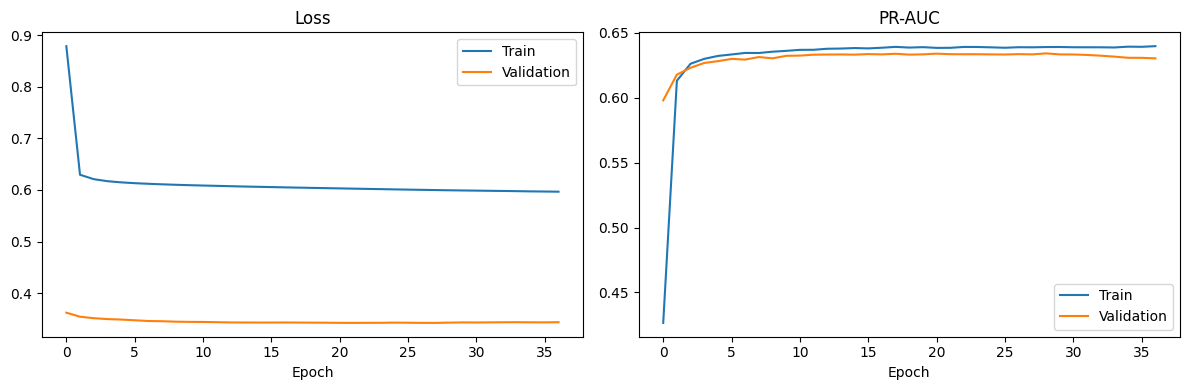

In [10]:
# Learning curves
h = history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(h["loss"], label="Train")
axes[0].plot(h["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(h["pr_auc"], label="Train")
axes[1].plot(h["val_pr_auc"], label="Validation")
axes[1].set_title("PR-AUC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate the model on validation data

**PR-AUC** is our main metric.

The random baseline is approximately the fraud rate.

In [11]:
p_val = model.predict(X_val_s, verbose=0).ravel()

val_pr_auc = average_precision_score(y_val, p_val)
val_roc_auc = roc_auc_score(y_val, p_val)

print(f"Validation PR-AUC : {val_pr_auc:.4f}")
print(f"Validation ROC-AUC: {val_roc_auc:.4f}")
print(f"Random PR-AUC     : {y_val.mean():.4f}")

Validation PR-AUC : 0.6329
Validation ROC-AUC: 0.9288
Random PR-AUC     : 0.0816


## 9. Choose a decision threshold

The neural network produces a probability. We still need to decide:

> At what probability should a transaction be flagged?

We choose the threshold using the **validation set**, then freeze it before testing.

Here we use the threshold that maximises **F1**.

In [12]:
precision, recall, thresholds = precision_recall_curve(y_val, p_val)

f1 = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = np.argmax(f1[:-1])
threshold = thresholds[best_idx]

print("Chosen threshold:", round(threshold, 3))
print("Precision:", round(precision[best_idx], 3))
print("Recall:   ", round(recall[best_idx], 3))
print("F1:       ", round(f1[best_idx], 3))

Chosen threshold: 0.871
Precision: 0.622
Recall:    0.628
F1:        0.625


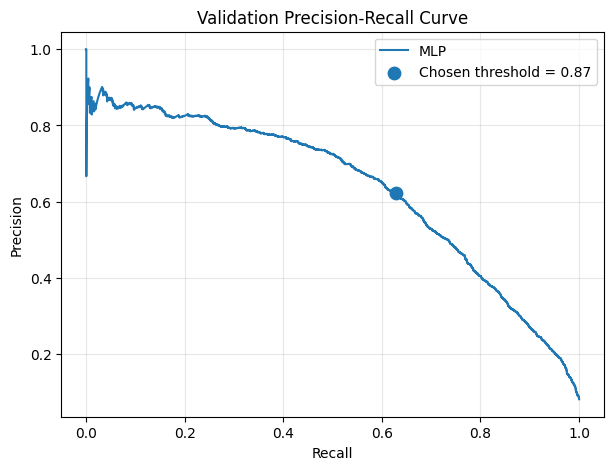

In [13]:
# Precision-recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label="MLP")
plt.scatter(
    recall[best_idx],
    precision[best_idx],
    s=80,
    label=f"Chosen threshold = {threshold:.2f}",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Final out-of-time test

The test set represents future transactions.

We now evaluate the model **once**, using the threshold chosen from validation.

In [14]:
p_test = model.predict(X_test_s, verbose=0).ravel()

test_pr_auc = average_precision_score(y_test, p_test)
test_roc_auc = roc_auc_score(y_test, p_test)

y_pred = (p_test >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"Test PR-AUC : {test_pr_auc:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Random PR-AUC: {y_test.mean():.4f}")

print("\nAt the frozen threshold:")
print(f"Alerts raised : {tp + fp:,}")
print(f"Fraud caught  : {tp:,} / {tp + fn:,}")
print(f"Recall        : {tp / (tp + fn):.1%}")
print(f"Precision     : {tp / (tp + fp):.1%}")
print(f"Fraud missed  : {fn:,}")

Test PR-AUC : 0.6287
Test ROC-AUC: 0.9311
Random PR-AUC: 0.0848

At the frozen threshold:
Alerts raised : 2,702
Fraud caught  : 1,645 / 2,628
Recall        : 62.6%
Precision     : 60.9%
Fraud missed  : 983


## 11. Summary

### What should you remember?

1. **Scale inputs** before training a neural network.
2. Fit preprocessing steps on **training data only**.
3. A simple MLP can be enough for a small tabular feature set.
4. Use **PR-AUC** rather than accuracy when the positive class is rare.
5. Use **early stopping** to control training and overfitting.
6. `class_weight` helps the model pay more attention to fraud.
7. A probability is not automatically a business decision — choose a **threshold**.
8. Choose the threshold on validation data and keep the **test set sealed**.
9. The final question is not whether the neural network is sophisticated, but whether it performs well enough on **future data**.